Import Libraries

In [4]:
import os, re, requests, json

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from   plotly.subplots import make_subplots
from   IPython.display import Image

from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.stattools import adfuller

from sklearn.linear_model import Ridge
# from xgboost import XGBRegressor
from sklearn.ensemble import GradientBoostingRegressor
#
# %matplotlib inline
#
# #pd.set_option('display.max_rows', None)
# pd.set_option('display.max_columns', None)
# #pd.set_option('display.max_colwidth', None)

Import the dataset

In [8]:
df_macro = pd.read_parquet('fred_prorcessed_daily.parquet')
df_macro_info = pd.read_parquet('fred_series.parquet')

df_macro.head()
no_shift_columns = ['DGS1MO', 'DGS3MO', 'DGS6MO', 'DGS1', 'DGS2', 'DGS3', 'DGS5', 'DGS7', 'DGS10', 'DGS20', 'DGS30']

daily_cols = [col for col in df_macro_info[df_macro_info['frequency_short'] == 'D']['id'].tolist() if col not in no_shift_columns]
weekly_cols = df_macro_info[df_macro_info['frequency_short'] == 'W']['id'].tolist()
print(daily_cols)
print(weekly_cols)
other_cols = [col for col in df_macro_info[~df_macro_info['frequency_short'].isin(['D', 'W'])]['id'].tolist() if col not in no_shift_columns]
#
df_macro[daily_cols] = df_macro[daily_cols].shift(1)
df_macro[weekly_cols] = df_macro[weekly_cols].shift(1)
df_macro[other_cols] = df_macro[other_cols].shift(1)
#
column_order = no_shift_columns + [col for col in df_macro.columns if col not in no_shift_columns]
df_macro = df_macro[column_order]

['DTB1YR', 'T10YIE', 'T10Y2Y', 'T10Y3M', 'T10YFF', 'SOFR180DAYAVG', 'DTB3', 'SOFR30DAYAVG', 'OBMMIFHA30YF', 'OBMMIJUMBO30YF', 'OBMMIVA30YF', 'DTB4WK', 'T5YIE', 'T5YIFR', 'DTB6', 'DCPF3M', 'SOFR90DAYAVG', 'RIFSPBLPND', 'VIXCLS', 'DEXCAUS', 'DEXCHUS', 'CBBTCUSD', 'DCOILWTICO', 'RIFSRPF02ND', 'DJIA', 'USEPUINDXD', 'EFFR', 'RIFSPFFNB', 'DFEDTARL', 'DFEDTARU', 'DFEDTAR', 'DHHNGSP', 'BAMLC4A0C710YEY', 'BAMLC0A2CAAEY', 'BAMLC0A2CAA', 'BAMLC0A1CAAAEY', 'BAMLC0A1CAAA', 'BAMLH0A1HYBBEY', 'BAMLH0A1HYBB', 'BAMLC0A4CBBBEY', 'BAMLC0A4CBBB', 'BAMLH0A3HYCEY', 'BAMLH0A3HYC', 'BAMLEMCBPIOAS', 'BAMLC0A3CAEY', 'BAMLC0A3CA', 'BAMLH0A2HYBEY', 'BAMLH0A2HYB', 'BAMLC0A0CMEY', 'BAMLC0A0CM', 'BAMLH0A0HYM2EY', 'BAMLH0A0HYM2', 'BAMLHYH0A0HYM2TRIV', 'IOER', 'DEXJPUS', 'DFII10', 'DFII30', 'DFII5', 'DEXMXUS', 'DAAA', 'AAA10Y', 'DBAA', 'BAA10Y', 'NASDAQ100', 'NASDAQCOM', 'USRECD', 'DTWEXBGS', 'OBFR', 'RPONTSYD', 'RRPONTSYAWARD', 'RRPONTTLD', 'RRPONTSYD', 'SP500', 'SOFRINDEX', 'SOFR', 'DEXKOUS', 'TEDRATE', 'THREEFYTP10

Filter the time periods in df that contain NaN values

In [9]:
df_macro = df_macro.loc['2011-01-01':'2023-12-31']
df_macro = df_macro.drop(columns=df_macro.isna().sum()[df_macro.isna().sum() > 200].index)
df_macro = df_macro.drop(columns=['GDPNOW','DFEDTAR','M0892AUSM156SNBR'])
print("Number of rows with NaN:", df_macro.isna().any(axis=1).sum())

Number of rows with NaN: 0


In [10]:
numeric_check = df_macro.iloc[:, 0:].apply(lambda col: pd.api.types.is_numeric_dtype(col))
non_numeric_cols = numeric_check[~numeric_check].index.tolist()
if len(non_numeric_cols) == 0: print("All columns from the second column onwards are numeric.")
else: print("The following columns are not numeric:", non_numeric_cols)

All columns from the second column onwards are numeric.


In [12]:
# cols_to_front = ['DGS1MO', 'DGS3MO','DGS6MO','DGS1', 'DGS2', 'DGS3','DGS5','DGS7','DGS10', 'DGS20','DGS30']
# remaining_cols = [col for col in df_macro.columns if col not in cols_to_front]
# new_order = cols_to_front + remaining_cols
# df_macro = df_macro[new_order]
# df_macro.head()
df_macro.to_parquet('fred_prorcessed_daily_shifted.parquet', index=True)

### Feature Selection

In [ ]:
feature_names = df_macro.iloc[:, 11:].columns
features = df_macro.iloc[:, 11:]
features_scaled = pd.DataFrame(StandardScaler().fit_transform(features),
                             columns=feature_names,
                             index=features.index)

threshold = 0.01

Ridge

In [ ]:
all_important_features_ridge = set()

for col in cols_to_front:
    ridge = Ridge(solver='svd',random_state=42)
    ridge.fit(features, df_macro[col])

    ridge_importance = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': ridge.coef_
    })
    ridge_importance['Abs_Coefficient'] = ridge_importance['Coefficient'].abs()
    ridge_importance = ridge_importance.sort_values('Abs_Coefficient', ascending=False)

    ridge_features = ridge_importance[ridge_importance['Abs_Coefficient'] > threshold]['Feature'].tolist()
    all_important_features_ridge.update(ridge_features)
    print(f"Ridge selected {len(ridge_features)} features for {col}:", ridge_features)

print("\n=== Final Ridge Important Features ===")
print(f"Total unique features: {len(all_important_features_ridge)}")
print(sorted(all_important_features_ridge))

Ridge selected 38 features for DGS1MO: ['DTB4WK', 'DTB3', 'GASREGW', 'T10Y3M', 'THREEFYTP10', 'IOER', 'GASDESW', 'T10YFF', 'BAMLC0A4CBBBEY', 'BAMLC0A2CAA', 'AAA10Y', 'BAMLEMCBPIOAS', 'T5YIE', 'MORTGAGE15US', 'BAMLC0A1CAAA', 'DEXUSUK', 'NFCI', 'BAMLH0A1HYBB', 'BAMLH0A2HYB', 'T10YIE', 'BAMLC0A1CAAAEY', 'DFII10', 'DFII30', 'ANFCI', 'TEDRATE', 'DTB6', 'BAMLC0A0CM', 'BAMLH0A2HYBEY', 'BAMLH0A3HYC', 'BAMLC0A3CA', 'BAA10Y', 'DTB1YR', 'T5YIFR', 'DEXCHUS', 'MORTGAGE30US', 'BAMLC0A4CBBB', 'RIFSRPF02ND', 'BAMLC0A2CAAEY']
Ridge selected 39 features for DGS3MO: ['DTB3', 'T10Y3M', 'DTB6', 'T10YFF', 'AAA10Y', 'DFII10', 'DBAA', 'BAMLC4A0C710YEY', 'BAA10Y', 'DAAA', 'T5YIE', 'DTB1YR', 'ANFCI', 'T10Y2Y', 'DTB4WK', 'GASDESW', 'T10YIE', 'DEXCHUS', 'MORTGAGE30US', 'BAMLC0A0CM', 'MORTGAGE15US', 'EFFR', 'RIFSPFFNB', 'BAMLC0A3CAEY', 'RIFSRPF02ND', 'BAMLH0A2HYB', 'BAMLC0A4CBBB', 'BAMLC0A4CBBBEY', 'BAMLC0A2CAA', 'BAMLC0A1CAAAEY', 'BAMLH0A1HYBBEY', 'MORTGAGE5US', 'T5YIFR', 'BAMLC0A0CMEY', 'NFCI', 'BAMLC0A3CA', 'IO

Gradient Boosting

In [ ]:
all_important_features_gb = set()

for col in cols_to_front:
    gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
    gb.fit(features_scaled, df_macro[col])

    gb_importance = pd.DataFrame({
        'Feature': feature_names,
        'Importance': gb.feature_importances_
    }).sort_values('Importance', ascending=False)

    gb_features = gb_importance[gb_importance['Importance'] > threshold]['Feature'].tolist()
    all_important_features_gb.update(gb_features)
    print(f"Gradient Boosting selected {len(gb_features)} features for {col}:",gb_features)

print("\n=== Final Gradient Boosting Important Features ===")
print(f"Total unique features: {len(all_important_features_gb)}")
print(sorted(all_important_features_gb))

Gradient Boosting selected 3 features for DGS1MO: ['DTB4WK', 'DTB3', 'WRMFNS']
Gradient Boosting selected 5 features for DGS3MO: ['DTB3', 'ADPWNUSNERSA', 'WRMFNS', 'WCURRNS', 'IR3TIB01USM156N']
Gradient Boosting selected 5 features for DGS6MO: ['DTB6', 'T10Y2Y', 'ADPWNUSNERSA', 'DTB1YR', 'DTB3']
Gradient Boosting selected 6 features for DGS1: ['DTB1YR', 'DTB3', 'DTB6', 'WRMFNS', 'WCURRNS', 'ADPWNUSNERSA']
Gradient Boosting selected 6 features for DGS2: ['DTB1YR', 'BAMLC0A1CAAAEY', 'DTB6', 'DTB3', 'WRMFNS', 'ADPWNUSNERSA']
Gradient Boosting selected 5 features for DGS3: ['BAMLC0A1CAAAEY', 'DTB1YR', 'WRMFNS', 'BAMLC0A2CAAEY', 'EXPINF30YR']
Gradient Boosting selected 5 features for DGS5: ['BAMLC0A1CAAAEY', 'REAINTRATREARAT10Y', 'MORTGAGE5US', 'BAMLC0A2CAAEY', 'EXPINF10YR']
Gradient Boosting selected 6 features for DGS7: ['MORTGAGE15US', 'REAINTRATREARAT10Y', 'BAMLC0A1CAAAEY', 'IRLTLT01USM156N', 'MORTGAGE5US', 'THREEFYTP10']
Gradient Boosting selected 6 features for DGS10: ['IRLTLT01USM156

XGBoost

In [ ]:
all_important_features_xgb = set()

for col in cols_to_front:
    xgb = XGBRegressor(n_estimators=100, random_state=42)
    xgb.fit(features_scaled, df_macro[col])

    xgb_importance = pd.DataFrame({
        'Feature': feature_names,
        'Importance': xgb.feature_importances_
    }).sort_values('Importance', ascending=False)

    xgb_features = xgb_importance[xgb_importance['Importance'] > threshold]['Feature'].tolist()
    all_important_features_xgb.update(xgb_features)
    print(f"XGBoost selected {len(xgb_features)} features for {col}:",xgb_features)

print("\n=== Final XGBoost Important Features ===")
print(f"Total unique features: {len(all_important_features_xgb)}")
print(sorted(all_important_features_xgb))

XGBoost selected 6 features for DGS1MO: ['DTB4WK', 'WCURRNS', 'CLSACBW027SBOG', 'WSHOSHO', 'MANEMP', 'DTB3']
XGBoost selected 7 features for DGS3MO: ['CLSACBW027SBOG', 'ADPWNUSNERSA', 'USCONS', 'DTB6', 'TOTBKCR', 'DTB3', 'WSHOSHO']
XGBoost selected 5 features for DGS6MO: ['WRMFNS', 'DTB6', 'MORTGAGE15US', 'WCURRNS', 'IR3TIB01USM156N']
XGBoost selected 7 features for DGS1: ['WRMFNS', 'DTB1YR', 'CLSACBW027SBOG', 'DTB3', 'MORTGAGE15US', 'ADPWNUSNERSA', 'TREAST']
XGBoost selected 11 features for DGS2: ['BAMLC0A1CAAAEY', 'CLSACBW027SBOG', 'DTB1YR', 'TOTCI', 'MORTGAGE15US', 'IRLTLT01USM156N', 'PPIDES', 'DEXVZUS', 'ASPUS', 'DRCRELEXFACBS', 'TCU']
XGBoost selected 8 features for DGS3: ['BAMLC0A1CAAAEY', 'CLSACBW027SBOG', 'WRMFNS', 'EXPINF30YR', 'WPU083', 'PCU325199325199P', 'FGEXPND', 'DTB1YR']
XGBoost selected 9 features for DGS5: ['REAINTRATREARAT10Y', 'BAMLC0A1CAAAEY', 'ADPWNUSNERSA', 'TERMCBCCALLNS', 'WPS101211', 'PCU483111483111', 'NETEXP', 'BAMLC0A2CAAEY', 'APU0000708111']
XGBoost select

Combined Results

In [ ]:
final_features = all_important_features_ridge.union(all_important_features_gb).union(all_important_features_xgb)
print("\n=== All Unique Important Features Across Methods ===")
print(f"Total unique features: {len(final_features)}")
print(sorted(final_features))


=== All Unique Important Features Across Methods ===
Total unique features: 96
['AAA10Y', 'ADPWNUSNERSA', 'AEXUSEU', 'ANFCI', 'APU0000708111', 'ASPUS', 'BAA10Y', 'BAMLC0A0CM', 'BAMLC0A0CMEY', 'BAMLC0A1CAAA', 'BAMLC0A1CAAAEY', 'BAMLC0A2CAA', 'BAMLC0A2CAAEY', 'BAMLC0A3CA', 'BAMLC0A3CAEY', 'BAMLC0A4CBBB', 'BAMLC0A4CBBBEY', 'BAMLC4A0C710YEY', 'BAMLEMCBPIOAS', 'BAMLH0A0HYM2', 'BAMLH0A0HYM2EY', 'BAMLH0A1HYBB', 'BAMLH0A1HYBBEY', 'BAMLH0A2HYB', 'BAMLH0A2HYBEY', 'BAMLH0A3HYC', 'BAMLH0A3HYCEY', 'CLSACBW027SBOG', 'CPIEDUSL', 'DAAA', 'DBAA', 'DCPF3M', 'DEXCAUS', 'DEXCHUS', 'DEXUSUK', 'DEXVZUS', 'DFEDTARL', 'DFEDTARU', 'DFII10', 'DFII30', 'DFII5', 'DRCLACBS', 'DRCRELEXFACBS', 'DTB1YR', 'DTB3', 'DTB4WK', 'DTB6', 'EFFR', 'EXPINF10YR', 'EXPINF1YR', 'EXPINF30YR', 'FGEXPND', 'GASDESW', 'GASREGW', 'H41RESPPALDKNWW', 'HQMCB10YR', 'IOER', 'IR3TIB01USM156N', 'IRLTLT01USM156N', 'MANEMP', 'MORTGAGE15US', 'MORTGAGE30US', 'MORTGAGE5US', 'NETEXP', 'NFCI', 'PCU325199325199P', 'PCU483111483111', 'PPIDES', 'PRIME'

In [ ]:
with open('Macro Factors.txt', 'w') as f:
    for feature in final_features:
        f.write(feature + '\n')

Feature Selection


=== Training Ridge ===
Test R² score: 0.999

=== Training Gradient Boosting ===
Test R² score: 0.999

=== Training XGBoost ===
Test R² score: 0.999


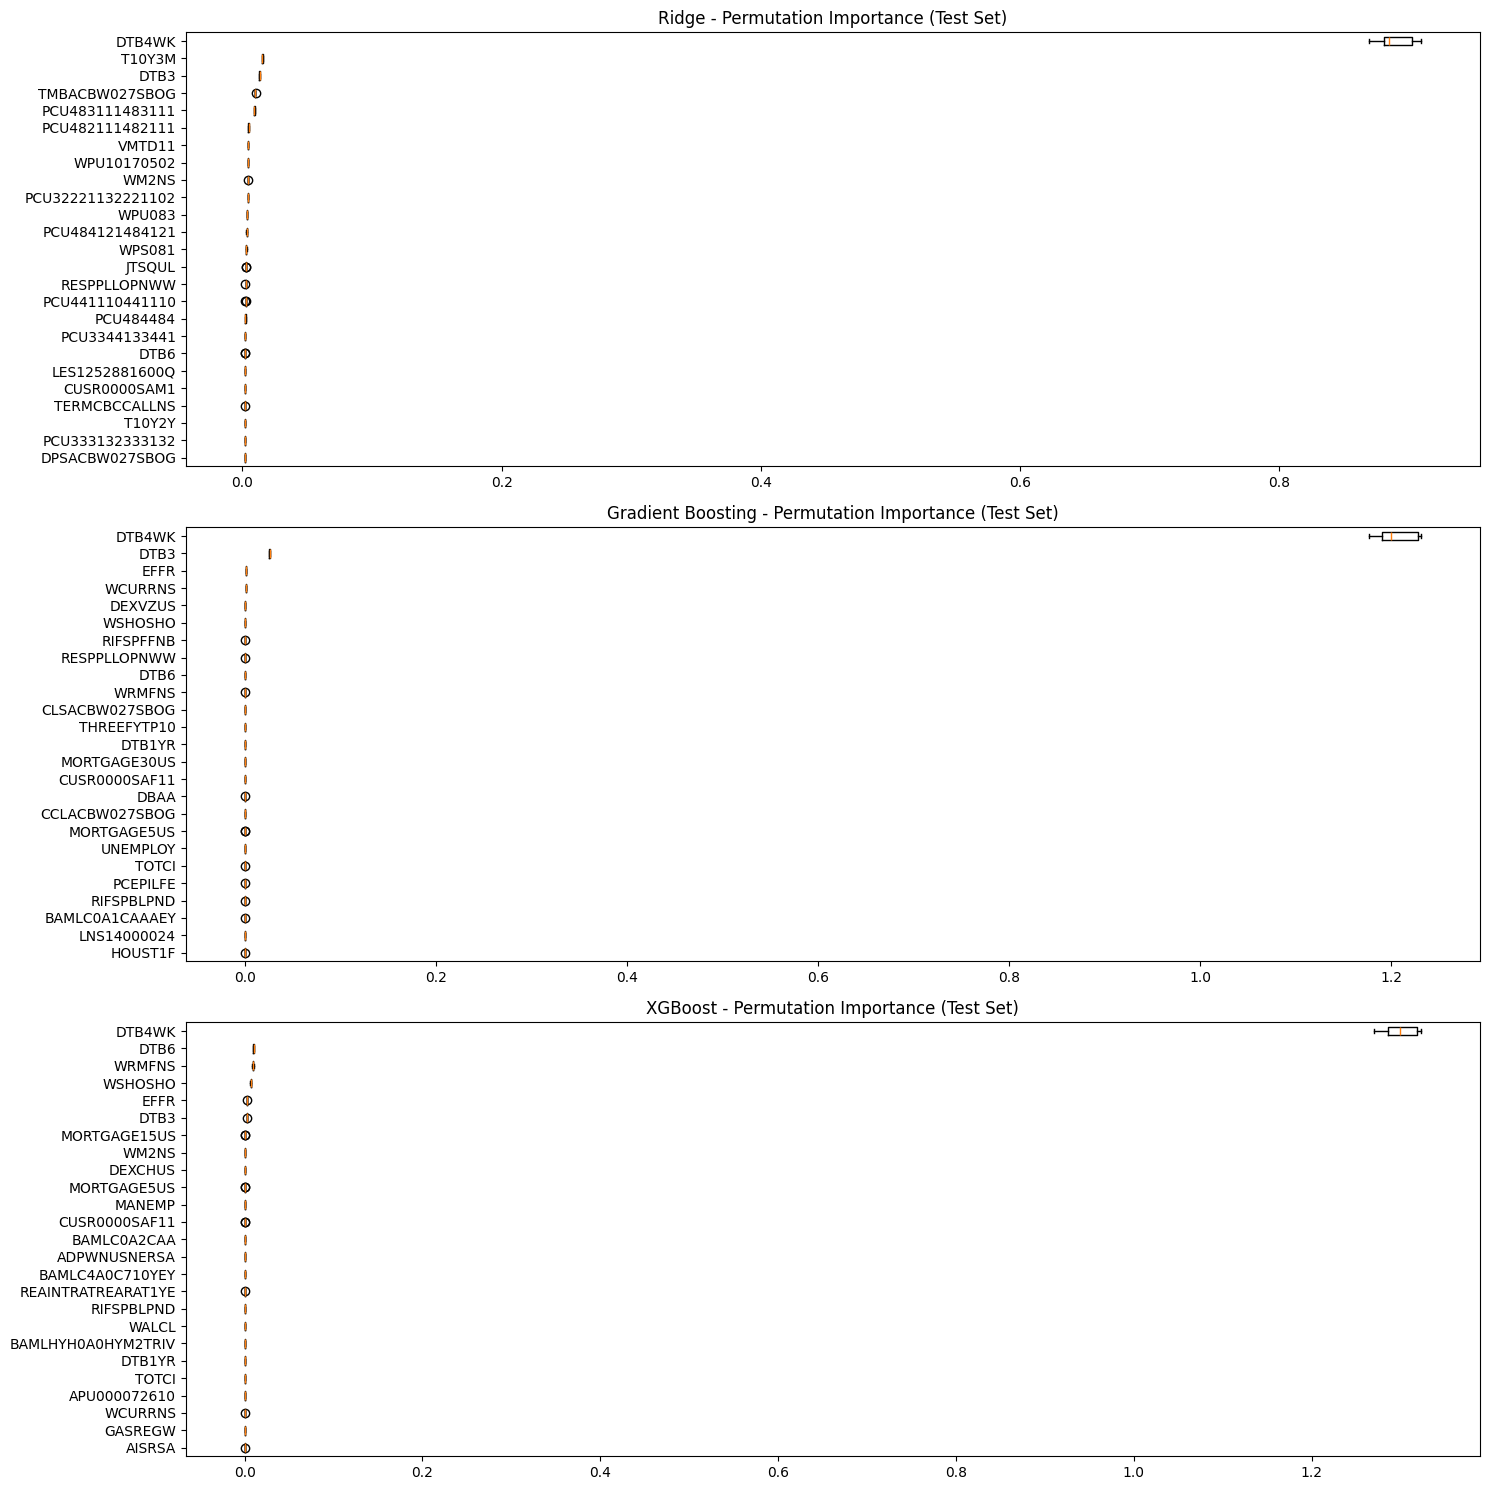


Ridge Top 50 Features:
['DTB4WK', 'T10Y3M', 'DTB3', 'TMBACBW027SBOG', 'PCU483111483111', 'PCU482111482111', 'PCU32221132221102', 'WPU10170502', 'WM2NS', 'VMTD11', 'WPU083', 'PCU484121484121', 'RESPPLLOPNWW', 'JTSQUL', 'WPS081', 'DTB6', 'PCU484484', 'LES1252881600Q', 'TERMCBCCALLNS', 'PCU3344133441', 'PCU333132333132', 'PCU441110441110', 'CUSR0000SAM1', 'APU0000702111', 'T10Y2Y', 'CCLACBW027SBOG', 'DPSACBW027SBOG', 'WPU0221', 'PCU325199325199P', 'GASREGW', 'PCU32723272', 'TOTLL', 'TOTCI', 'CREACBW027SBOG', 'THREEFYTP10', 'WPU571', 'IR3TIB01USM156N', 'CORCCACBS', 'PCU311421311421', 'PCU332991332991', 'WPS101211', 'DRCCLACBS', 'JTSLDR', 'DFII30', 'WPU10', 'PSAVERT', 'CDSP', 'PCUAWHLTRAWHLTR', 'GASDESW', 'PERMIT']

Gradient Boosting Top 50 Features:
['DTB4WK', 'DTB3', 'EFFR', 'WCURRNS', 'RIFSPFFNB', 'DEXVZUS', 'RESPPLLOPNWW', 'WSHOSHO', 'CLSACBW027SBOG', 'WRMFNS', 'MORTGAGE5US', 'DTB6', 'CCLACBW027SBOG', 'PCEPILFE', 'DBAA', 'CREACBW027SBOG', 'CUSR0000SAF11', 'TOTCI', 'T10Y3M', 'HOUST1F', 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.pipeline import make_pipeline

# 1. Data Preparation
feature_names = df_macro.iloc[:, 11:].columns
features = df_macro.iloc[:, 11:]
targets = df_macro[cols_to_front]  # Assume cols_to_front contains target variables

# 2. Data Standardization
scaler = StandardScaler()
features_scaled = pd.DataFrame(scaler.fit_transform(features),
                             columns=feature_names,
                             index=features.index)

# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    features_scaled,
    targets.iloc[:, 0],  # Using first target variable for demonstration
    test_size=0.3,
    random_state=42
)

# 4. Model Definitions
models = {
    "Ridge": make_pipeline(StandardScaler(), Ridge(alpha=1.0, random_state=42)),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42)
}

# 5. Model Training and Evaluation
results = {}
for name, model in models.items():
    print(f"\n=== Training {name} ===")
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    print(f"Test R² score: {score:.3f}")

    # Feature Importance Analysis
    if name == "Ridge":
        coef = model.named_steps['ridge'].coef_
        importance = pd.DataFrame({'Feature': feature_names, 'Importance': np.abs(coef)})
    else:
        importance = pd.DataFrame({'Feature': feature_names, 'Importance': model.feature_importances_})

    importance = importance.sort_values('Importance', ascending=False)
    results[name] = importance

# 6. Permutation Importance Analysis
plt.figure(figsize=(15, 15))
for i, (name, model) in enumerate(models.items(), 1):
    # Use 20% of test data for faster computation
    subset_size = int(0.2 * len(X_test))
    X_test_subset, _, y_test_subset, _ = train_test_split(
        X_test, y_test,
        test_size=subset_size,
        random_state=42
    )

    result = permutation_importance(
        model, X_test_subset, y_test_subset,
        n_repeats=5,
        random_state=42,
        n_jobs=-1
    )

    # Visualize Top 50 Features
    sorted_idx = result.importances_mean.argsort()[-25:]
    plt.subplot(3, 1, i)
    plt.boxplot(
        result.importances[sorted_idx].T,
        vert=False,
        tick_labels=np.array(feature_names)[sorted_idx]
    )
    plt.title(f"{name} - Permutation Importance (Test Set)")
    plt.tight_layout()

plt.show()

# 7. Consolidated Important Features
top_n = 50
final_features = {}
for name, importance in results.items():
    top_features = importance.nlargest(top_n, 'Importance')['Feature'].tolist()
    final_features[name] = top_features
    print(f"\n{name} Top {top_n} Features:")
    print(top_features)

# Find features considered important by all three models
common_features = set(final_features["Ridge"]) & set(final_features["Gradient Boosting"]) & set(final_features["XGBoost"])
print("\n=== Common Important Features ===")
print(sorted(common_features))

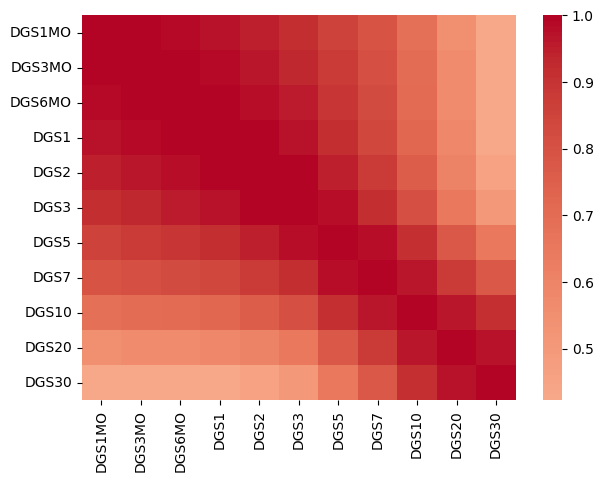

In [ ]:
plt.figure(figsize=(7,5))
sns.heatmap(df_macro[df_macro.columns[:len(cols_to_front)]].corr(), cmap='coolwarm', center=0)
plt.show()